In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

# Add src to path
sys.path.append(os.path.abspath('..'))

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version : 2.11.0+cpu
Device          : cpu


In [2]:
class BrainTumorDataset(Dataset):
    def __init__(self, img_paths, mask_paths, augment=False, img_size=256):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.img_size   = img_size
        self.augment    = augment

        self.aug_transforms = A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.1, scale_limit=0.1,
                rotate_limit=15, p=0.4,
                border_mode=0
            ),
            A.ElasticTransform(alpha=120, sigma=120*0.05, p=0.2),
            A.RandomBrightnessContrast(
                brightness_limit=0.2,
                contrast_limit=0.2, p=0.4
            ),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
            ToTensorV2()
        ])

        self.basic_transforms = A.Compose([
            A.Resize(img_size, img_size),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Load image as grayscale
        img  = np.array(
            Image.open(self.img_paths[idx]).convert('L'),
            dtype=np.float32
        )
        mask = np.array(
            Image.open(self.mask_paths[idx]).convert('L'),
            dtype=np.float32
        )

        # Normalize image to [0, 1]
        img = img / 255.0

        # Convert mask to binary class labels
        # 0 = background, 1 = tumor
        mask_bin = np.zeros_like(mask, dtype=np.int64)
        mask_bin[mask > 127] = 1

        if self.augment:
            aug = self.aug_transforms(
                image=img,
                mask=mask_bin.astype(np.float32)
            )
        else:
            aug = self.basic_transforms(
                image=img,
                mask=mask_bin.astype(np.float32)
            )

        image_tensor = aug['image'].float()    # shape: (1, H, W)
        mask_tensor  = aug['mask'].long()      # shape: (H, W)

        return image_tensor, mask_tensor

In [3]:
train_df = pd.read_csv(r'C:\Users\Ismail\Documents\medical-segmentation\data\splits\train.csv')
val_df   = pd.read_csv(r'C:\Users\Ismail\Documents\medical-segmentation\data\splits\val.csv')
test_df  = pd.read_csv(r'C:\Users\Ismail\Documents\medical-segmentation\data\splits\test.csv')

# ── Use only 20% of data for fast training ──
train_df = train_df.sample(frac=0.2, random_state=42).reset_index(drop=True)
val_df   = val_df.sample(frac=0.2, random_state=42).reset_index(drop=True)

IMG_SIZE    = 128   # ← reduced from 256 to 128 (4x faster)
BATCH_SIZE  = 16    # ← increased for faster iterations
NUM_WORKERS = 0     # ← keep 0 on Windows

train_dataset = BrainTumorDataset(
    train_df['image'].tolist(),
    train_df['mask'].tolist(),
    augment  = True,
    img_size = IMG_SIZE
)
val_dataset = BrainTumorDataset(
    val_df['image'].tolist(),
    val_df['mask'].tolist(),
    augment  = False,
    img_size = IMG_SIZE
)
test_dataset = BrainTumorDataset(
    test_df['image'].tolist(),
    test_df['mask'].tolist(),
    augment  = False,
    img_size = IMG_SIZE
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=8,          shuffle=False, num_workers=NUM_WORKERS)

print(f"✅ Train : {len(train_dataset)} samples | {len(train_loader)} batches")
print(f"✅ Val   : {len(val_dataset)} samples | {len(val_loader)} batches")

imgs, masks = next(iter(train_loader))
print(f"✅ Batch image shape : {imgs.shape}")
print(f"✅ Mask unique values: {masks.unique().tolist()}")

C:\Users\Ismail\anaconda3\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\Ismail\AppData\Local\Temp\ipykernel_10892\2569864712.py:23: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


✅ Train : 429 samples | 27 batches
✅ Val   : 92 samples | 6 batches
✅ Batch image shape : torch.Size([16, 1, 128, 128])
✅ Mask unique values: [0, 1]


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# ── MobileNetV2 = 4x lighter than ResNet34, much faster on CPU ──
model = smp.Unet(
    encoder_name    = "mobilenet_v2",   # ← changed from resnet34
    encoder_weights = "imagenet",
    in_channels     = 1,
    classes         = 2,
    activation      = None
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Training on: cpu
Total parameters: 6,628,514


In [5]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        # preds: (B, C, H, W) raw logits
        # targets: (B, H, W) long
        preds = torch.softmax(preds, dim=1)
        targets_one_hot = torch.zeros_like(preds)
        targets_one_hot.scatter_(1, targets.unsqueeze(1), 1)

        intersection = (preds * targets_one_hot).sum(dim=(2, 3))
        union        = preds.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))
        dice         = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()


ce_loss   = nn.CrossEntropyLoss()
dice_loss = DiceLoss()

def combined_loss(preds, targets):
    return 0.5 * ce_loss(preds, targets) + 0.5 * dice_loss(preds, targets)

print("✅ Loss functions ready")

✅ Loss functions ready


In [6]:
EPOCHS    = 30
LR        = 1e-4

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=4, factor=0.5
)

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for imgs, masks in tqdm(loader, desc="  Training", leave=False):
        imgs  = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="  Validating", leave=False):
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            loss  = combined_loss(preds, masks)
            total_loss += loss.item()
    return total_loss / len(loader)

print("✅ Training setup ready")

✅ Training setup ready


In [7]:
import time

best_val_loss = float('inf')
train_losses  = []
val_losses    = []

EPOCHS = 10   # ← reduced from 30 to 10

os.makedirs('outputs/checkpoints', exist_ok=True)
print(f"🚀 Starting training for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss   = validate(model, val_loader)
    scheduler.step(val_loss)

    elapsed = time.time() - start
    remaining = elapsed * (EPOCHS - epoch)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    saved = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'outputs/checkpoints/best_model.pth')
        saved = " ✅ Saved!"

    print(f"Epoch [{epoch:02d}/{EPOCHS}] | "
          f"Train: {train_loss:.4f} | "
          f"Val: {val_loss:.4f} | "
          f"⏱ {elapsed:.0f}s | "
          f"ETA: {remaining/60:.1f}min"
          f"{saved}")

print(f"\n🎉 Training complete! Best Val Loss: {best_val_loss:.4f}")

🚀 Starting training for 10 epochs...



Epoch [01/10] | Train: 0.4420 | Val: 0.4489 | ⏱ 92s | ETA: 13.8min ✅ Saved!


Epoch [02/10] | Train: 0.3654 | Val: 0.3529 | ⏱ 92s | ETA: 12.3min ✅ Saved!


Epoch [03/10] | Train: 0.3264 | Val: 0.3118 | ⏱ 86s | ETA: 10.0min ✅ Saved!


Epoch [04/10] | Train: 0.3065 | Val: 0.2956 | ⏱ 92s | ETA: 9.2min ✅ Saved!


...

Epoch [06/10] | Train: 0.2832 | Val: 0.2700 | ⏱ 88s | ETA: 5.9min ✅ Saved!


Epoch [07/10] | Train: 0.2734 | Val: 0.2549 | ⏱ 89s | ETA: 4.4min ✅ Saved!


Epoch [08/10] | Train: 0.2619 | Val: 0.2401 | ⏱ 90s | ETA: 3.0min ✅ Saved!


Epoch [09/10] | Train: 0.2516 | Val: 0.2278 | ⏱ 99s | ETA: 1.6min ✅ Saved!


Epoch [10/10] | Train: 0.2454 | Val: 0.2130 | ⏱ 85s | ETA: 0.0min ✅ Saved!

🎉 Training complete! Best Val Loss: 0.2130


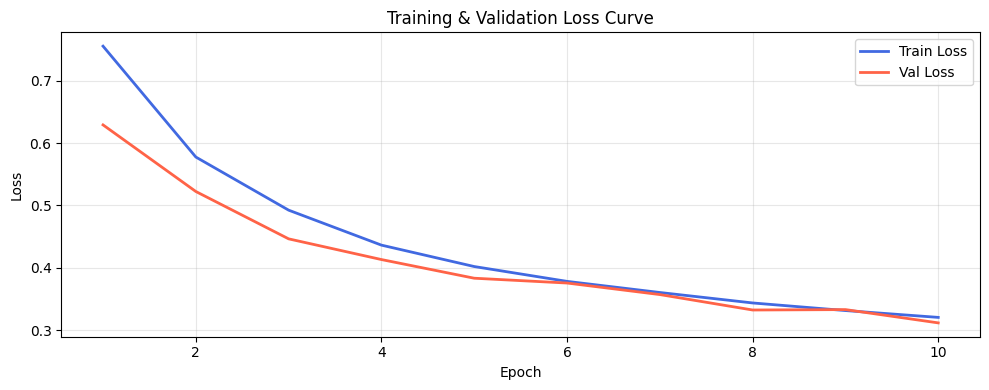

✅ Loss curve saved to outputs/loss_curve.png


In [9]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_losses)+1), train_losses,
         label='Train Loss', color='royalblue', linewidth=2)
plt.plot(range(1, len(val_losses)+1),   val_losses,
         label='Val Loss',   color='tomato',    linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/loss_curve.png', dpi=150)
plt.show()
print("✅ Loss curve saved to outputs/loss_curve.png")